<a href="https://colab.research.google.com/github/JoshiRawr/CCADMACL_EXERCISES_COM231ML/blob/main/Exercise5b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 5B

Classic dataset about geyser eruptions.

Each row represents an observed eruption of the Old Faithful Geyser in Yellowstone National Park. The eruptions column represents the duration of the eruption in minutes, and the waiting column represents the duration in minutes until the next eruption.

In this exercise, you will perform the following:
- Load and visualize a real 2D dataset
- Fit a Gaussian Mixture Model using sklearn
- Interpret GMM parameters (means, covariances, weights)
- Understand soft clustering via responsibilities
- Compare GMM with K-means
- Use log-likelihood and BIC for model selection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [2]:
url = "https://gist.githubusercontent.com/hogwild/c2704a1ae38c0a36983bc13121050dac/raw/oldFaithfulGeyserDataset.csv?raw=True"

df = pd.read_csv(url)

1. Load and understand the dataset
- Inspect the first 5 rows using `.head()`
- Inspected the total number of rows and columns using `.info()`

In [3]:
print("=" * 60)
print("1. Dataset Overview")
print("=" * 60)
print("\nFirst 5 rows:")
print(df.head())

print("\n\nDataset Info:")
print(df.info())

print(f"\nShape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nBasic statistics:")
print(df.describe())

1. Dataset Overview

First 5 rows:
   index  eruptions  waiting
0      1      3.600       79
1      2      1.800       54
2      3      3.333       74
3      4      2.283       62
4      5      4.533       85


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   index      272 non-null    int64  
 1   eruptions  272 non-null    float64
 2   waiting    272 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 6.5 KB
None

Shape: 272 rows, 3 columns

Column names: ['index', 'eruptions', 'waiting']

Basic statistics:
            index   eruptions     waiting
count  272.000000  272.000000  272.000000
mean   136.500000    3.487783   70.897059
std     78.663842    1.141371   13.594974
min      1.000000    1.600000   43.000000
25%     68.750000    2.162750   58.000000
50%    136.500000    4.000000   76.000000
75%    204.250000    4.454

2. Visualize the raw data
- Create a scatter plot of eruption duration vs waiting time.
- Label the axes.
- Describe the visible cluster structure.


2. Data Visualization


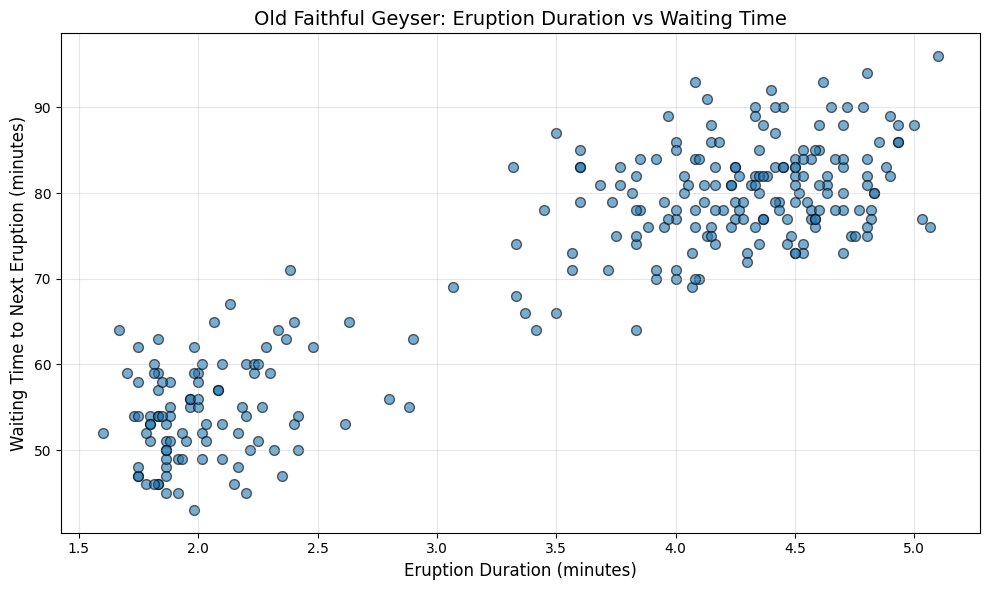


Observation: The data shows two distinct clusters:
- Cluster 1: Shorter eruptions (~2 min) with shorter waiting times (~55 min)
- Cluster 2: Longer eruptions (~4-5 min) with longer waiting times (~80 min)
This suggests a bimodal distribution in the geyser's behavior.


In [4]:
print("\n" + "=" * 60)
print("2. Data Visualization")
print("=" * 60)

plt.figure(figsize=(10, 6))
plt.scatter(df['eruptions'], df['waiting'], alpha=0.6, edgecolors='k', s=50)
plt.xlabel('Eruption Duration (minutes)', fontsize=12)
plt.ylabel('Waiting Time to Next Eruption (minutes)', fontsize=12)
plt.title('Old Faithful Geyser: Eruption Duration vs Waiting Time', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('geyser_raw_data.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nObservation: The data shows two distinct clusters:")
print("- Cluster 1: Shorter eruptions (~2 min) with shorter waiting times (~55 min)")
print("- Cluster 2: Longer eruptions (~4-5 min) with longer waiting times (~80 min)")
print("This suggests a bimodal distribution in the geyser's behavior.")

2. Fit a 2-component GMM

Fit a GMM with:
- `n_components=2`
- `covariance_type="full"`
- `random_state=42`

In [6]:

X = df[['eruptions', 'waiting']].values

gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X)

print("GMM fitted successfully!")
print(f"Converged: {gmm.converged_}")
print(f"Number of iterations: {gmm.n_iter_}")

GMM fitted successfully!
Converged: True
Number of iterations: 4


3. Inspect learned parameters

Print the following variables:
- Mixing coefficients `(gmm.weights_)`
- Means `(gmm.means_)`
- Covariance matrices `(gmm.covariances_)`

In [7]:
print("\nMixing Coefficients (Weights):")
print(gmm.weights_)
print(f"Component 0: {gmm.weights_[0]:.4f} ({gmm.weights_[0]*100:.1f}%)")
print(f"Component 1: {gmm.weights_[1]:.4f} ({gmm.weights_[1]*100:.1f}%)")

print("\nMeans:")
print(gmm.means_)
print(f"Component 0: Eruption={gmm.means_[0,0]:.3f} min, Waiting={gmm.means_[0,1]:.3f} min")
print(f"Component 1: Eruption={gmm.means_[1,0]:.3f} min, Waiting={gmm.means_[1,1]:.3f} min")

print("\nCovariance Matrices:")
for i in range(2):
    print(f"\nComponent {i}:")
    print(gmm.covariances_[i])


Mixing Coefficients (Weights):
[0.64407255 0.35592745]
Component 0: 0.6441 (64.4%)
Component 1: 0.3559 (35.6%)

Means:
[[ 4.28977944 79.96953298]
 [ 2.03652149 54.47986018]]
Component 0: Eruption=4.290 min, Waiting=79.970 min
Component 1: Eruption=2.037 min, Waiting=54.480 min

Covariance Matrices:

Component 0:
[[ 0.16982046  0.93871793]
 [ 0.93871793 36.02497019]]

Component 1:
[[ 0.06927449  0.43627723]
 [ 0.43627723 33.70493352]]


4. Compute cluster responsibilities
- Use `predict_proba()` to compute responsibilities.
- Select a point near the overlap region.
- Print its responsibility values.

In [8]:

responsibilities = gmm.predict_proba(X)

# Find a point near the overlap region (around eruption=3, waiting=65)
distances_to_boundary = np.abs(X[:, 0] - 3) + np.abs(X[:, 1] - 65)
overlap_idx = np.argmin(distances_to_boundary)

print(f"\nPoint near overlap region (index {overlap_idx}):")
print(f"Eruption: {X[overlap_idx, 0]:.3f} min, Waiting: {X[overlap_idx, 1]:.3f} min")
print(f"\nResponsibilities:")
print(f"Cluster 0: {responsibilities[overlap_idx, 0]:.4f} ({responsibilities[overlap_idx, 0]*100:.1f}%)")
print(f"Cluster 1: {responsibilities[overlap_idx, 1]:.4f} ({responsibilities[overlap_idx, 1]*100:.1f}%)")
print("\nThis shows the soft assignment - the point belongs partially to both clusters.")


Point near overlap region (index 83):
Eruption: 2.633 min, Waiting: 65.000 min

Responsibilities:
Cluster 0: 0.0056 (0.6%)
Cluster 1: 0.9944 (99.4%)

This shows the soft assignment - the point belongs partially to both clusters.


5. Hard assignment from GMM
- Use `.predict` to convert responsibilities into hard cluster labels.

In [10]:

gmm_labels = gmm.predict(X)

print(f"Cluster assignments (first 10): {gmm_labels[:10]}")
print(f"\nCluster 0: {np.sum(gmm_labels == 0)} points ({np.sum(gmm_labels == 0)/len(gmm_labels)*100:.1f}%)")
print(f"Cluster 1: {np.sum(gmm_labels == 1)} points ({np.sum(gmm_labels == 1)/len(gmm_labels)*100:.1f}%)")

Cluster assignments (first 10): [0 1 0 1 0 1 0 0 1 0]

Cluster 0: 175 points (64.3%)
Cluster 1: 97 points (35.7%)


6. Plot clusters found by GMM
- Plot the data colored by GMM cluster assignment.

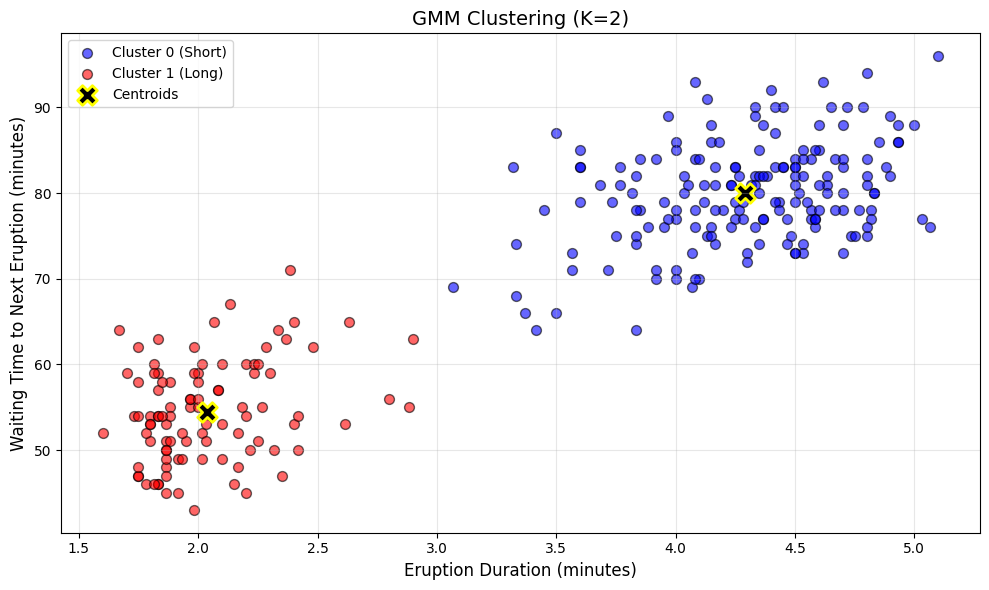

GMM clustering plot created!


In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(X[gmm_labels == 0, 0], X[gmm_labels == 0, 1],
            c='blue', label='Cluster 0 (Short)', alpha=0.6, edgecolors='k', s=50)
plt.scatter(X[gmm_labels == 1, 0], X[gmm_labels == 1, 1],
            c='red', label='Cluster 1 (Long)', alpha=0.6, edgecolors='k', s=50)
plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1],
            c='black', marker='X', s=200, edgecolors='yellow', linewidths=2, label='Centroids')
plt.xlabel('Eruption Duration (minutes)', fontsize=12)
plt.ylabel('Waiting Time to Next Eruption (minutes)', fontsize=12)
plt.title('GMM Clustering (K=2)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gmm_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print("GMM clustering plot created!")

7. Compare with K-means
- Fit K-means with k=2 and plot the result.

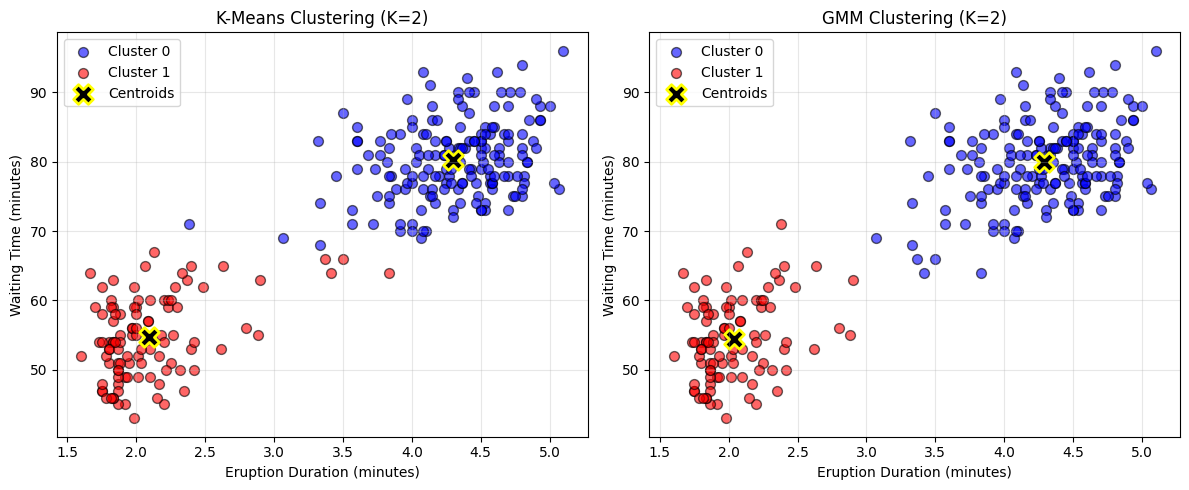


Agreement between K-means and GMM: 98.2%

Key difference: GMM provides soft assignments (probabilities),
while K-means only provides hard assignments.


In [12]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

plt.figure(figsize=(12, 5))

# K-means plot
plt.subplot(1, 2, 1)
plt.scatter(X[kmeans_labels == 0, 0], X[kmeans_labels == 0, 1],
            c='blue', label='Cluster 0', alpha=0.6, edgecolors='k', s=50)
plt.scatter(X[kmeans_labels == 1, 0], X[kmeans_labels == 1, 1],
            c='red', label='Cluster 1', alpha=0.6, edgecolors='k', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='black', marker='X', s=200, edgecolors='yellow', linewidths=2, label='Centroids')
plt.xlabel('Eruption Duration (minutes)')
plt.ylabel('Waiting Time (minutes)')
plt.title('K-Means Clustering (K=2)')
plt.legend()
plt.grid(True, alpha=0.3)

# GMM plot
plt.subplot(1, 2, 2)
plt.scatter(X[gmm_labels == 0, 0], X[gmm_labels == 0, 1],
            c='blue', label='Cluster 0', alpha=0.6, edgecolors='k', s=50)
plt.scatter(X[gmm_labels == 1, 0], X[gmm_labels == 1, 1],
            c='red', label='Cluster 1', alpha=0.6, edgecolors='k', s=50)
plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1],
            c='black', marker='X', s=200, edgecolors='yellow', linewidths=2, label='Centroids')
plt.xlabel('Eruption Duration (minutes)')
plt.ylabel('Waiting Time (minutes)')
plt.title('GMM Clustering (K=2)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_vs_gmm.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate agreement
agreement = np.sum(kmeans_labels == gmm_labels) / len(kmeans_labels)
print(f"\nAgreement between K-means and GMM: {agreement*100:.1f}%")
print("\nKey difference: GMM provides soft assignments (probabilities),")
print("while K-means only provides hard assignments.")

8. Log-likelihood of the data
- Compute the average log-likelihood under the model.

In [13]:
log_likelihood = gmm.score(X)
total_log_likelihood = gmm.score(X) * len(X)

print(f"Average log-likelihood per sample: {log_likelihood:.4f}")
print(f"Total log-likelihood: {total_log_likelihood:.4f}")
print("\nHigher log-likelihood indicates better fit to the data.")

Average log-likelihood per sample: -4.1554
Total log-likelihood: -1130.2641

Higher log-likelihood indicates better fit to the data.


9. Model selection with BIC
- Fit GMMs with different numbers of components and compute BIC.


BIC and AIC scores for different numbers of components:
K	BIC		AIC
1	2607.62		2589.59
2	2322.19		2282.53
3	2349.08		2287.78
4	2362.27		2279.34
5	2371.08		2266.51
6	2401.18		2274.98

Best number of components (lowest BIC): 2


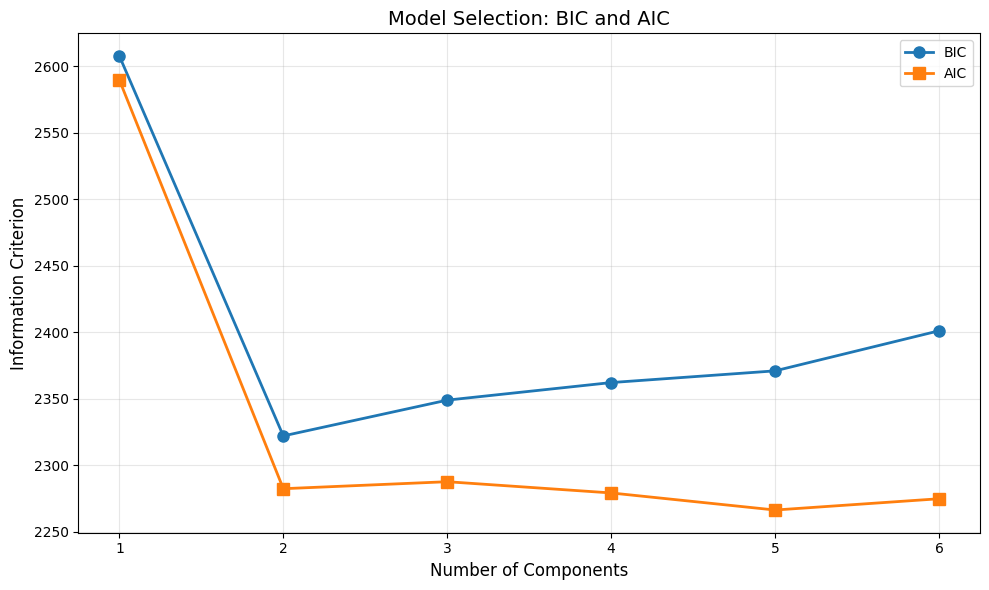


Lower BIC/AIC values indicate better models.
BIC penalizes model complexity more heavily than AIC.


In [14]:
n_components_range = range(1, 7)
bic_scores = []
aic_scores = []

for n in n_components_range:
    gmm_temp = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    gmm_temp.fit(X)
    bic_scores.append(gmm_temp.bic(X))
    aic_scores.append(gmm_temp.aic(X))

print("\nBIC and AIC scores for different numbers of components:")
print("K\tBIC\t\tAIC")
for n, bic, aic in zip(n_components_range, bic_scores, aic_scores):
    print(f"{n}\t{bic:.2f}\t\t{aic:.2f}")

best_n = n_components_range[np.argmin(bic_scores)]
print(f"\nBest number of components (lowest BIC): {best_n}")

plt.figure(figsize=(10, 6))
plt.plot(n_components_range, bic_scores, 'o-', label='BIC', linewidth=2, markersize=8)
plt.plot(n_components_range, aic_scores, 's-', label='AIC', linewidth=2, markersize=8)
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Information Criterion', fontsize=12)
plt.title('Model Selection: BIC and AIC', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(n_components_range)
plt.tight_layout()
plt.savefig('bic_aic_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLower BIC/AIC values indicate better models.")
print("BIC penalizes model complexity more heavily than AIC.")

10. Standardize the data
- Apply standardization to the dataset.
- Refit the GMM and compare results.

Original data statistics:
Eruptions - Mean: 3.488, Std: 1.139
Waiting - Mean: 70.897, Std: 13.570

Standardized data statistics:
Eruptions - Mean: 0.000, Std: 1.000
Waiting - Mean: 0.000, Std: 1.000


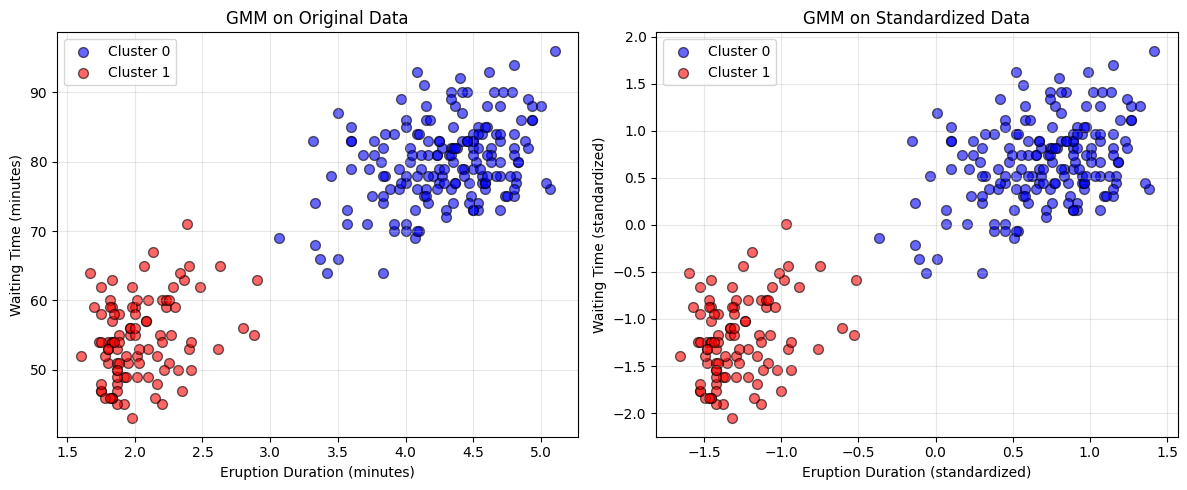



Comparison of Results:
Original data - BIC: 2322.19
Standardized data - BIC: 832.59

Agreement between original and standardized GMM: 100.0%


Key Insights:
- Standardization puts features on the same scale
- For this dataset, results are similar with/without standardization
- Standardization is more important when features have very different scales
- GMM is less sensitive to scale than K-means when using 'full' covariance


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original data statistics:")
print(f"Eruptions - Mean: {X[:, 0].mean():.3f}, Std: {X[:, 0].std():.3f}")
print(f"Waiting - Mean: {X[:, 1].mean():.3f}, Std: {X[:, 1].std():.3f}")

print("\nStandardized data statistics:")
print(f"Eruptions - Mean: {X_scaled[:, 0].mean():.3f}, Std: {X_scaled[:, 0].std():.3f}")
print(f"Waiting - Mean: {X_scaled[:, 1].mean():.3f}, Std: {X_scaled[:, 1].std():.3f}")

# Fit GMM on standardized data
gmm_scaled = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm_scaled.fit(X_scaled)
gmm_scaled_labels = gmm_scaled.predict(X_scaled)

plt.figure(figsize=(12, 5))

# Original scale
plt.subplot(1, 2, 1)
plt.scatter(X[gmm_labels == 0, 0], X[gmm_labels == 0, 1],
            c='blue', label='Cluster 0', alpha=0.6, edgecolors='k', s=50)
plt.scatter(X[gmm_labels == 1, 0], X[gmm_labels == 1, 1],
            c='red', label='Cluster 1', alpha=0.6, edgecolors='k', s=50)
plt.xlabel('Eruption Duration (minutes)')
plt.ylabel('Waiting Time (minutes)')
plt.title('GMM on Original Data')
plt.legend()
plt.grid(True, alpha=0.3)

# Standardized scale
plt.subplot(1, 2, 2)
plt.scatter(X_scaled[gmm_scaled_labels == 0, 0], X_scaled[gmm_scaled_labels == 0, 1],
            c='blue', label='Cluster 0', alpha=0.6, edgecolors='k', s=50)
plt.scatter(X_scaled[gmm_scaled_labels == 1, 0], X_scaled[gmm_scaled_labels == 1, 1],
            c='red', label='Cluster 1', alpha=0.6, edgecolors='k', s=50)
plt.xlabel('Eruption Duration (standardized)')
plt.ylabel('Waiting Time (standardized)')
plt.title('GMM on Standardized Data')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('standardized_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n\nComparison of Results:")
print(f"Original data - BIC: {gmm.bic(X):.2f}")
print(f"Standardized data - BIC: {gmm_scaled.bic(X_scaled):.2f}")

agreement_scaled = np.sum(gmm_labels == gmm_scaled_labels) / len(gmm_labels)
print(f"\nAgreement between original and standardized GMM: {agreement_scaled*100:.1f}%")

print("\n\nKey Insights:")
print("- Standardization puts features on the same scale")
print("- For this dataset, results are similar with/without standardization")
print("- Standardization is more important when features have very different scales")
print("- GMM is less sensitive to scale than K-means when using 'full' covariance")
